In [10]:
import pandas as pd
data = pd.read_csv("digit-recognizer/train.csv")
data.head()


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

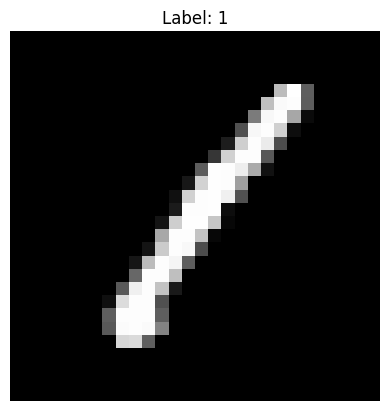

In [21]:
import matplotlib.pyplot as plt
idx = 0
row = data.iloc[idx]
label = row["label"]
pixels = row.drop("label").values.reshape(28, 28)
plt.imshow(pixels, cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")

In [11]:
data.shape


(42000, 785)

In [12]:
y = data['label']
X = data.drop('label', axis=1)
y.shape


(42000, 784)

In [13]:
X.shape

(42000, 784)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape

(33600, 784)

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3,5,10,None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
dt = DecisionTreeClassifier(random_state=42)
classifier = GridSearchCV(estimator=dt, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
classifier.fit(X_train, y_train)
predictions = classifier.predict(X_val)
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_val, predictions)
print(f"Validation Accuracy: {accuracy:.4f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Validation Accuracy: 0.8623


In [23]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

cat = CatBoostClassifier(
    iterations=500,
    depth=8,
    learning_rate=0.1,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100,
    task_type="GPU",
)
cat.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=100)
preds = cat.predict(X_val)
cat_acc = accuracy_score(y_val, preds)
print(f"CatBoost Validation Accuracy: {cat_acc:.4f}")

0:	learn: 0.6959524	test: 0.6946429	best: 0.6946429 (0)	total: 378ms	remaining: 3m 8s
100:	learn: 0.9774702	test: 0.9565476	best: 0.9565476 (95)	total: 17.2s	remaining: 1m 8s
200:	learn: 0.9841369	test: 0.9634524	best: 0.9634524 (198)	total: 28.3s	remaining: 42s
300:	learn: 0.9879464	test: 0.9661905	best: 0.9669048 (293)	total: 39.3s	remaining: 26s
400:	learn: 0.9905357	test: 0.9678571	best: 0.9679762 (397)	total: 50.3s	remaining: 12.4s
499:	learn: 0.9924107	test: 0.9692857	best: 0.9692857 (469)	total: 1m 1s	remaining: 0us
bestTest = 0.9692857143
bestIteration = 469
Shrink model to first 470 iterations.
CatBoost Validation Accuracy: 0.9693


In [29]:
sample = pd.read_csv("digit-recognizer/sample_submission.csv")
test_data = pd.read_csv("digit-recognizer/test.csv")
test_data.shape

(28000, 784)

In [30]:
sample = pd.read_csv("digit-recognizer/sample_submission.csv")
test_data = pd.read_csv("digit-recognizer/test.csv")
test_data.shape
test_preds = cat.predict(test_data).reshape(-1)
submission = pd.DataFrame({"ImageId": sample["ImageId"], "Label": test_preds.astype(int)})
submission.to_csv("submission.csv", index=False)
submission.shape

(28000, 2)

In [ ]:
import torch
import torch.nn as nn
class KCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
            ,nn.BatchNorm2d(32)
            ,nn.LeakyReLU(0.1)
            ,nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1)
            ,nn.BatchNorm2d(32)
            ,nn.LeakyReLU(0.1)
            ,nn.MaxPool2d(kernel_size=2, stride=2)
            ,nn.Dropout(0.25)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
            ,nn.BatchNorm2d(64)
            ,nn.LeakyReLU(0.1)
            ,nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
            ,nn.BatchNorm2d(64)
            ,nn.LeakyReLU(0.1)
            ,nn.MaxPool2d(kernel_size=2, stride=2)
            ,nn.Dropout(0.25)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
            ,nn.BatchNorm2d(128)
            ,nn.LeakyReLU(0.1)
            ,nn.MaxPool2d(kernel_size=2, stride=2)
            ,nn.Dropout(0.25)
        )
        self.fc = nn.Sequential(
            nn.Flatten()
            ,nn.Linear(128*3*3, 256)
            ,nn.BatchNorm1d(256)
            ,nn.LeakyReLU(0.1)
            ,nn.Dropout(0.5)
            ,nn.Linear(256, 10)
        )
    def forward(self, x):
        x= self.block1(x)
        x= self.block2(x)
        x= self.block3(x)
        logits = self.fc(x)
        return logits
    
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
class DigitDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        image = self.data[idx].reshape(1, 28, 28).astype('float32') / 255.0
        label = self.labels[idx]
        return torch.tensor(image), torch.tensor(label)
data = pd.read_csv("digit-recognizer/train.csv")
labels = data['label'].values
images = data.drop('label', axis=1).values
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.2, random_state=42)
train_dataset = DigitDataset(X_train, y_train)
val_dataset = DigitDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
import torch.optim as optim
device = torch.device("cuda")
model = KCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct= 0
    total =0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    acc = correct / total
    print (f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss:.4f}, Accuracy: {acc:.4f}")
    avg_loss = total_loss / len(train_loader)


Epoch [1/10], Loss: 112.1586, Accuracy: 0.9403
Epoch [2/10], Loss: 36.2502, Accuracy: 0.9789
Epoch [3/10], Loss: 28.9321, Accuracy: 0.9829
Epoch [4/10], Loss: 25.2341, Accuracy: 0.9849
Epoch [5/10], Loss: 21.3801, Accuracy: 0.9881
Epoch [6/10], Loss: 20.5609, Accuracy: 0.9877
Epoch [7/10], Loss: 18.4232, Accuracy: 0.9896
Epoch [8/10], Loss: 18.0510, Accuracy: 0.9899
Epoch [9/10], Loss: 17.3120, Accuracy: 0.9896
Epoch [10/10], Loss: 15.1816, Accuracy: 0.9907


In [37]:
import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

class KCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
,nn.BatchNorm2d(32)
,nn.LeakyReLU(0.1)
,nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1)
,nn.BatchNorm2d(32)
,nn.LeakyReLU(0.1)
,nn.MaxPool2d(kernel_size=2, stride=2)
,nn.Dropout(0.25)
)
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
,nn.BatchNorm2d(64)
,nn.LeakyReLU(0.1)
,nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1)
,nn.BatchNorm2d(64)
,nn.LeakyReLU(0.1)
,nn.MaxPool2d(kernel_size=2, stride=2)
,nn.Dropout(0.25)
)
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
,nn.BatchNorm2d(128)
,nn.LeakyReLU(0.1)
,nn.MaxPool2d(kernel_size=2, stride=2)
,nn.Dropout(0.25)
)
        self.fc = nn.Sequential(
            nn.Flatten()
,nn.Linear(128*3*3, 256)
,nn.BatchNorm1d(256)
,nn.LeakyReLU(0.1)
,nn.Dropout(0.5)
,nn.Linear(256, 10)
)
    def forward(self, x):
        x= self.block1(x)
        x= self.block2(x)
        x= self.block3(x)
        logits = self.fc(x)
        return logits
   
train_trainsforms = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.RandomRotation(10),
        transforms.RandomAffine(0, translate=(0.3, 0.3), scale=(0.8, 1.2)),
        transforms.ToTensor(),
    ]
)
val_trainsforms = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.ToTensor(),
    ]
)
class DigitDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images.reshape(-1, 28, 28).astype("uint8")
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        else:
            image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0
        return image, torch.tensor(label, dtype=torch.long)
import pandas as pd
from sklearn.model_selection import train_test_split
data = pd.read_csv("digit-recognizer/train.csv")
labels = data['label'].values
images = data.drop('label', axis=1).values
X_train, X_val, y_train, y_val = train_test_split(images, labels, test_size=0.1, random_state=42)
train_dataset = DigitDataset(X_train, y_train, transform=train_trainsforms)
val_dataset = DigitDataset(X_val, y_val, transform=val_trainsforms)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)         
device = torch.device("cuda")

model = KCNN().to(device)

criterion = nn.CrossEntropyLoss()
import torch.optim as optim
optimizer = optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
num_epochs = 30
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

best_val_acc = 0.0
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    correct, total = 0, 0
    for imgs,lbls in train_loader:
        imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += lbls.size(0)
        correct += (predicted == lbls).sum().item()
    scheduler.step()
    avg_train_loss = train_loss / total
    train_acc = correct / total
    model.eval()
    val_loss = 0.0
    correct, total = 0, 0
    if epoch % 5 == 0:
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                val_loss += loss.item() * imgs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += lbls.size(0)
                correct += (predicted == lbls).sum().item()
        val_acc = correct / total
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f} - "
              f"Val Loss: {val_loss/total:.4f}, Val Acc: {val_acc:.4f} - "
              f"LR: {current_lr:.6f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_kcnn.pth")
            print(f"New best model saved with val acc: {best_val_acc:.4f}")
        


Epoch [1/30] - Train Loss: 0.6139, Train Acc: 0.7983 - Val Loss: 0.1408, Val Acc: 0.9581 - LR: 0.002992
New best model saved with val acc: 0.9581
Epoch [6/30] - Train Loss: 0.1290, Train Acc: 0.9616 - Val Loss: 0.0241, Val Acc: 0.9921 - LR: 0.002714
New best model saved with val acc: 0.9921
Epoch [11/30] - Train Loss: 0.0963, Train Acc: 0.9706 - Val Loss: 0.0251, Val Acc: 0.9910 - LR: 0.002110
Epoch [16/30] - Train Loss: 0.0774, Train Acc: 0.9770 - Val Loss: 0.0192, Val Acc: 0.9926 - LR: 0.001343
New best model saved with val acc: 0.9926
Epoch [21/30] - Train Loss: 0.0650, Train Acc: 0.9800 - Val Loss: 0.0160, Val Acc: 0.9940 - LR: 0.000618
New best model saved with val acc: 0.9940
Epoch [26/30] - Train Loss: 0.0560, Train Acc: 0.9834 - Val Loss: 0.0150, Val Acc: 0.9943 - LR: 0.000130
New best model saved with val acc: 0.9943


In [40]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd

test_data = pd.read_csv("digit-recognizer/test.csv").values

class TestDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        image = self.data[idx].reshape(1, 28, 28).astype("float32") / 255.0
        return torch.tensor(image)

test_dataset = TestDataset(test_data)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

with torch.no_grad():
    model.load_state_dict(torch.load("best_kcnn.pth"))
    model.eval()
    all_preds = []
    for imgs in test_loader:
        imgs = imgs.to(device, non_blocking=True)
        outputs = model(imgs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
submission = pd.DataFrame({"ImageId": range(1, len(all_preds) + 1), "Label": all_preds})
submission.to_csv("kcnn_submission2.csv", index=False)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15192\693686858.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_kcnn.pth"))


In [41]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.transforms.functional as TF
import pandas as pd

test_data = pd.read_csv("digit-recognizer/test.csv").values

class TestDataset(Dataset):
    def __init__(self, data):
        self.data = data
        self.to_tensor = transforms.ToTensor()
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        image = self.data[idx].reshape(28, 28).astype("uint8")
        image = self.to_tensor(image)
        return image

test_dataset = TestDataset(test_data)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

def pred_with_tta_batch(model, imgs):
    preds = []
    model.eval()
    with torch.no_grad():
        for img in imgs:
            aug_list = [
                img,
                TF.rotate(img, angle=10),
                TF.affine(img, angle=0, translate=(5, 5), scale=1.0, shear=0),
                TF.affine(img, angle=0, translate=(-5, -5), scale=1.0, shear=0),
            ]
            aug_batch = torch.stack(aug_list).to(device)
            probs = torch.softmax(model(aug_batch), dim=1).mean(dim=0)
            preds.append(int(torch.argmax(probs).item()))
    return preds

model.load_state_dict(torch.load("best_kcnn.pth"))
all_preds = []
for imgs in test_loader:
    imgs = imgs.to(device, non_blocking=True)
    all_preds.extend(pred_with_tta_batch(model, imgs.cpu()))

submission = pd.DataFrame({"ImageId": range(1, len(all_preds) + 1), "Label": all_preds})
submission.to_csv("kcnn_submission3.csv", index=False)

C:\Users\Admin\AppData\Local\Temp\ipykernel_15192\3822994251.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_kcnn.pth"))


In [ ]:
import numpy as np
sample = pd.read_csv("digit-recognizer/sample_submission.csv")
test_data = pd.read_csv("digit-recognizer/test.csv").values
class TestDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        image = self.data[idx].reshape(1, 28, 28).astype("float32") / 255.0
        return torch.tensor(image)
test_dataset = TestDataset(test_data)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
model.eval()
all_preds = []
with torch.no_grad():
    for images in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.append(preds)
test_preds = np.concatenate(all_preds)
submission = pd.DataFrame({"ImageId": sample["ImageId"], "Label": test_preds.astype(int)})
submission.to_csv("submission.csv", index=False)
submission.shape

KCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.1)
    (6)